In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
# custom
import custom.models as mod
import custom.tools as tl

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

h5file= "L1_70_12_6_6.h5"
h5_path = f"/mnt/eph/data/{h5file}"

cuda


# Univariate

## Loading

In [2]:
# with open('/mnt/eph/deepsea_optune/trial_6/losses_60.pickle', 'rb') as fin: losses = pickle.load(fin)
# if type(losses['train'][0]) is torch.Tensor: losses['train'] = [loss.item() for loss in losses['train']]  # fix if using old tl.train_epoch without .item()
    
optuna_save = torch.load('/mnt/eph/data/optuna/artifacts/8226070b-ac47-45d0-9e66-13a7efbf804b', weights_only=False)  # for run parameters if needed
for key, item in optuna_save.items():
    if "dict" not in key and 'losses' != key: print(key, item)
# losses = optuna_save['losses']

train_set_params {'path': '/mnt/eph/data/L1_70_12_6_6.h5', 'name': 'A', 'win_len': 100, 'win_stride': 60}
train_loader_params {'batch_size': 64, 'num_workers': 10, 'pin_memory': True, 'drop_last': False, 'persistent_workers': True}
val_set_params {'path': '/mnt/eph/data/L1_70_12_6_6.h5', 'name': 'B', 'win_len': 100, 'win_stride': 60}
val_loader_params {'batch_size': 64, 'num_workers': 10, 'pin_memory': True, 'drop_last': False, 'persistent_workers': True}
epoch 30
clip 3.9336641849119425


# Losses

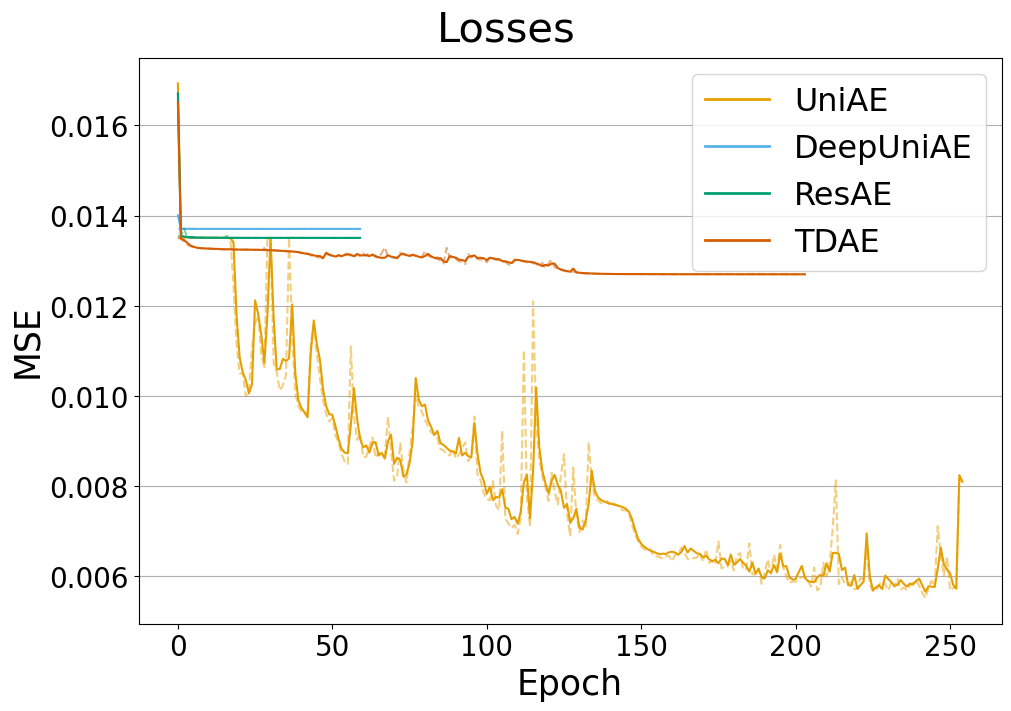

In [26]:
train = {}
val = {}
models = ['UniAE', 'DeepUniAE', 'ResAE']
C = ['#E69F00', '#56B4E9', '#009E73', "#D55E00"]

for loss, model in zip(['/mnt/eph/uni_feat_model_stuff/trial_20/losses_255.pickle',
    '/mnt/eph/deepsea_optune/trial_6/losses_60.pickle',
    '/mnt/eph/resae_optuning/training/losses_60.pickle'
             ], models):
    with open(loss, 'rb') as fin: losses = pickle.load(fin)
    train[model] = losses['train']
    val[model] = losses['val']

models += ['TDAE']
multi = torch.load('/mnt/eph/multi_feat_model_stuff/trials/item2_20_epoch202.pt', weights_only=False)
train['TDAE'] = multi['losses']['train']
val['TDAE'] = multi['losses']['val']

train['DeepUniAE'] = [loss + .0002 for loss in train['DeepUniAE']]
val['DeepUniAE'] = [loss + .0002 for loss in val['DeepUniAE']]

fig, ax = plt.subplots(figsize=(10,7), layout='constrained')
fig.suptitle(f'Losses', fontsize=30)
for i, model in enumerate(models):
    ax.plot(train[model], c=C[i], label=model)
    ax.plot(val[model], c=C[i], ls='--', alpha=.5)
    

# ax.plot(train, label='Training')
# ax.plot(val, label='Validation')
ax.set_xlabel('Epoch', fontsize=25)
ax.set_ylabel('MSE', fontsize=25)
ax.tick_params(labelsize=20)
ax.grid(which='both', axis='y')
leg = ax.legend(fontsize=23)
for line in leg.get_lines(): line.set_linewidth(2)
# plt.savefig('/mnt/eph/report_figures/losses.pdf')  ######### DANGER ZONE #########
plt.show()

In [42]:
multi = torch.load('/mnt/eph/multi_feat_model_stuff/trials/item2_20_epoch202.pt', weights_only=False)
multi['losses']

{'train': [0.01650916381769783,
  0.013490998897455878,
  0.013456744295391407,
  0.013401716538182982,
  0.013340599067345426,
  0.013312064541073946,
  0.013291192793666006,
  0.013281405673126925,
  0.013274881451462325,
  0.01327159062314492,
  0.013267031671213252,
  0.013264995999634266,
  0.013261991721874738,
  0.013263011617319924,
  0.013255240979021067,
  0.01325419654680805,
  0.01325312873942184,
  0.013254951977344987,
  0.013248925788102897,
  0.013248273642262914,
  0.013249565320150865,
  0.013247400629692353,
  0.013247217435471631,
  0.013245253076592644,
  0.013244288646012218,
  0.01324345553191481,
  0.013241856901364013,
  0.013239182398787566,
  0.013236626859877136,
  0.013236952050087543,
  0.013231745301899347,
  0.013230024279187342,
  0.013227960509299249,
  0.013221351747083795,
  0.013217630647736919,
  0.01321479185883488,
  0.013209841490446865,
  0.013205809262837027,
  0.013199437691082994,
  0.013191151811362623,
  0.013177749470572223,
  0.013162326

In [21]:
dicts_save = torch.load('/mnt/eph/uni_feat_model_stuff/trial_20/mod_opt_scal_235.pt')

In [3]:
## Gio
h5file= "L1_70_12_6_6.h5"
h5_path = f"/mnt/eph/data/{h5file}"


batch_size = 1

# win_len = t_set.win_len
# win_stride = t_set.win_stride
num_workers = 0 #os.cpu_count() if os.cpu_count() is not None else 0
persistent_workers = False
#test = h5set(h5_path,win_len=win_len, win_stride=win_stride, name='C') #10k rows
test = tl.h5set(h5_path,win_len=100, win_stride=60, name='C') #10k rows
test_loader = DataLoader(test,
                batch_size=batch_size,
                shuffle=False,
                pin_memory=False,
                num_workers=num_workers,
                persistent_workers=persistent_workers,
                drop_last=True,
                )
#sq_len = test.__getitem__(0).shape[0]
#input_size =  test.__getitem__(0).shape[1]
model = torch.compile(mod.ResAE(dropout=0, reg=True).to(device))
model.load_state_dict(optuna_save['model_state_dict'])

<All keys matched successfully>

# GG recon

In [9]:
a = torch.vstack(list(test_loader)[:3000])
a.std()

tensor(0.1162)

In [121]:
## test_function gio
model.eval()
loss_ew = nn.MSELoss(reduction='none')
test_loss = []
with torch.no_grad():
    for batch_data in tl.tqdm(test_loader):
        batch_data = batch_data.reshape(-1, 100, 1).to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16): out = model(batch_data)
        ew_loss = loss_ew(out, batch_data)
        # ew_loss = torch.hstack([ew_loss[0, 0, :]] + [ew_loss[i, -win_stride:, 0] for i in range(1, ew_loss.shape[0])])  # pointwise
        ew_loss = ew_loss.mean(dim=1)
        test_loss.append(ew_loss.squeeze(-1))


100%|██████████████████████████████████████████████████████████████████| 12000/12000 [01:00<00:00, 198.33it/s]


In [122]:
print(len(test_loss))
# test_loss = [loss.squeeze(-1) for loss in test_loss]
print(test_loss[0].shape)

12000
torch.Size([272])


In [123]:
grid = torch.vstack(test_loss).cpu().numpy()

In [124]:
# grid = all_window_losses.numpy()


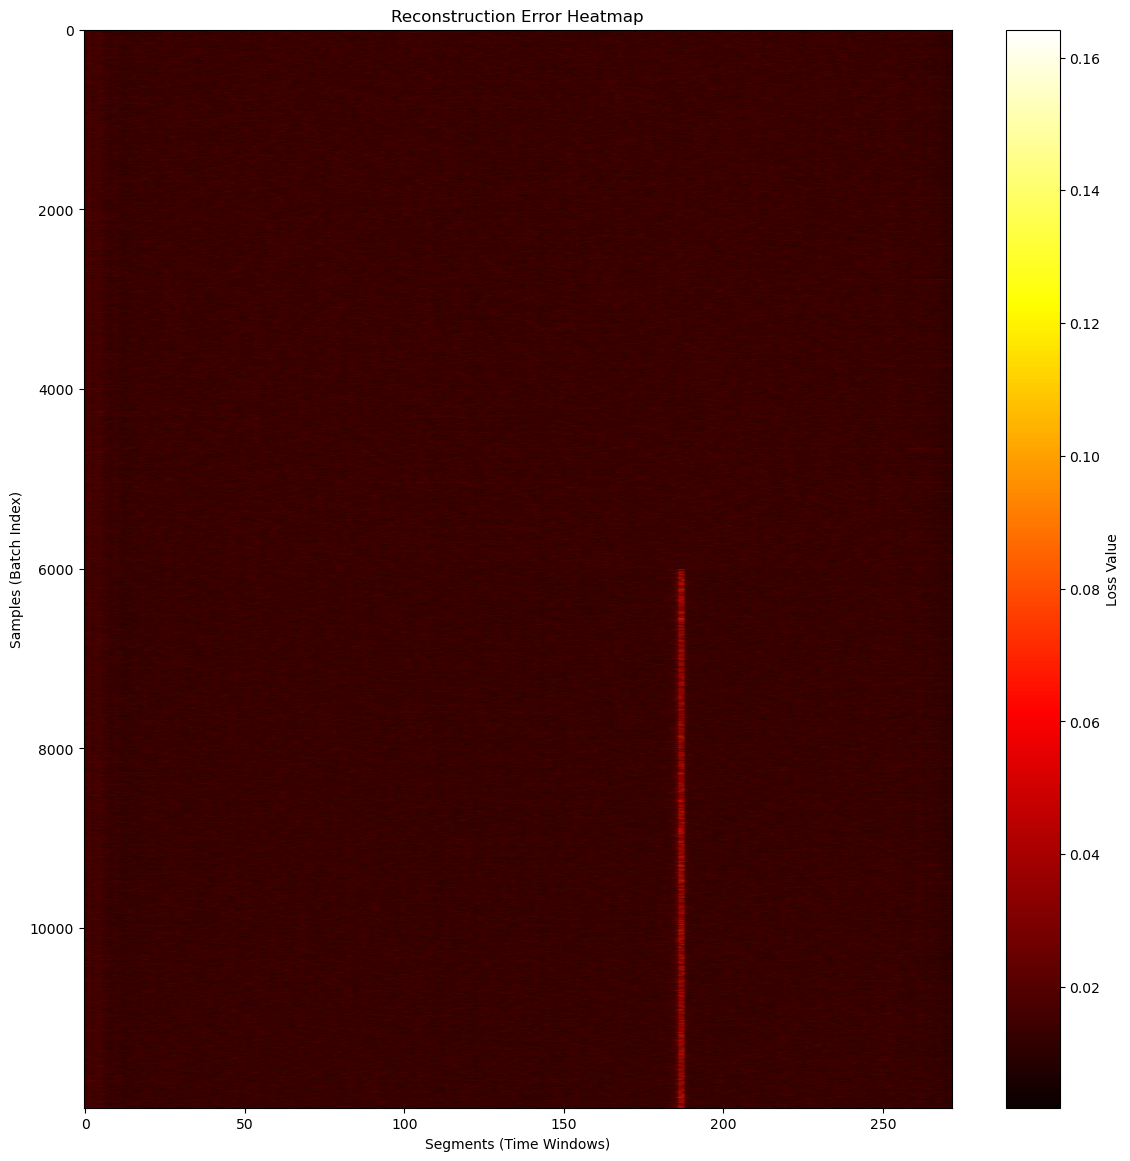

In [125]:
# Assuming 'data' is your 2D array (e.g., the [N, R] losses)
# If it's a Torch tensor, make sure to move it to CPU and convert to numpy:
# data = all_window_losses.cpu().numpy()

plt.figure(figsize=(14, 14))

# 1. Plot the heatmap
# 'aspect=auto' stretches the heatmap to fill the box (crucial for non-square matrices)
# 'interpolation=nearest' ensures pixels are crisp, not blurry
plt.imshow(grid, cmap='hot', aspect='auto')#, interpolation='nearest')

# 2. Add a colorbar (legend for values)
plt.colorbar(label='Loss Value')

# 3. Add Labels
plt.xlabel('Segments (Time Windows)')
plt.ylabel('Samples (Batch Index)')
plt.title('Reconstruction Error Heatmap')

plt.show()

# Reconstruction

In [5]:
### Test Loaders
win_len_uni = 100
win_stride_uni = 60
win_len_multi = 48
win_stride_multi = 42

batch_size = 1
num_workers = 1
persistent_workers = False

runs = {'UniAE': {'model': mod.LSTMAEUni(),
                  'path': '/mnt/eph/uni_feat_model_stuff/trial_20/mod_opt_scal_235.pt'},
        'DeepUniAE': {'model': mod.DeepAE(h_s1=128, n_l1=2, h_s2=32, n_l2=2, h_s3=8, n_l3=3, dropout=.5, reg=False),
                      'path': '/mnt/eph/deepsea_optune/trial_6/mod_opt_scal_60.pt'},
        'ResAE': {'model': mod.ResAE(dropout=.25, reg=False),
                  'path': '/mnt/eph/resae_optuning/training/mod_opt_scal_60.pt'},
        'TDAE': {'model': mod.AEric2(sq_len=389, num_feat=48, exp_dim=768, compr_dim=192, num_layers=2),
                 'path': '/mnt/eph/multi_feat_model_stuff/trials/item2_20_epoch202.pt'},
        }
         

test_uni = tl.h5set(h5_path, win_len=win_len_uni, win_stride=win_stride_uni, name='C')
test_multi = tl.h5set(h5_path, win_len=win_len_multi, win_stride=win_stride_multi, name='C')

test_loader_uni = DataLoader(test_uni, batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=num_workers, persistent_workers=persistent_workers, drop_last=True)
test_loader_multi = DataLoader(test_multi, batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=num_workers, persistent_workers=persistent_workers, drop_last=True)

sample_uni = next(iter(test_loader_uni)).reshape(-1, win_len_uni, 1).to(device)  # WARNING only if batch_size=1
sample_multi = next(iter(test_loader_multi)).to(device)
print(sample_uni.shape)
print(sample_multi.shape)
del test_loader_uni, test_loader_multi


out = {'UniAE': {'zorder': 2.01, 'C': '#E69F00'},
       'DeepUniAE': {'zorder': 2.03, 'C': '#56B4E9'},
       'ResAE': {'zorder': 2.04, 'C': '#009E73'},
       'TDAE': {'zorder': 2.02, 'C': '#D55E00'}
      }
for key, item in runs.items():
    print(key)
    model = torch.compile(item['model'].to(device))
    model.load_state_dict(torch.load(item['path'])['model_state_dict'])
    model.eval()
    with torch.no_grad():
        with torch.autocast(device_type=str(device), dtype=torch.float16):
            if key != 'TDAE':
                mod_out = model(sample_uni)
                print(f"{mod_out.shape=}")
                mod_out = torch.hstack([mod_out[0, :, 0]] + [mod_out[i, -win_stride_uni:, 0] for i in range(1, mod_out.shape[0])]).to('cpu')
                print(f"{mod_out.shape=}")
            else:
                mod_out = model(sample_multi)
                print(f"{mod_out.shape=}")
                mod_out = torch.hstack([mod_out[0, 0, :]] + [mod_out[0, i, -win_stride_multi:] for i in range(1, mod_out.shape[1])]).to('cpu')
                print(f"{mod_out.shape=}")
            out[key]['rec'] = mod_out
del runs, model

torch.Size([272, 100, 1])
torch.Size([1, 389, 48])
UniAE
mod_out.shape=torch.Size([272, 100, 1])
mod_out.shape=torch.Size([16360])
DeepUniAE
mod_out.shape=torch.Size([272, 100, 1])
mod_out.shape=torch.Size([16360])
ResAE
mod_out.shape=torch.Size([272, 100, 1])
mod_out.shape=torch.Size([16360])
TDAE
mod_out.shape=torch.Size([1, 389, 48])
mod_out.shape=torch.Size([16344])


In [ ]:
## offset DeepUniAE to avoid overlap
# out['DeepUniAE']['rec'] = [val + .01 for val in out['DeepUniAE']['rec']]

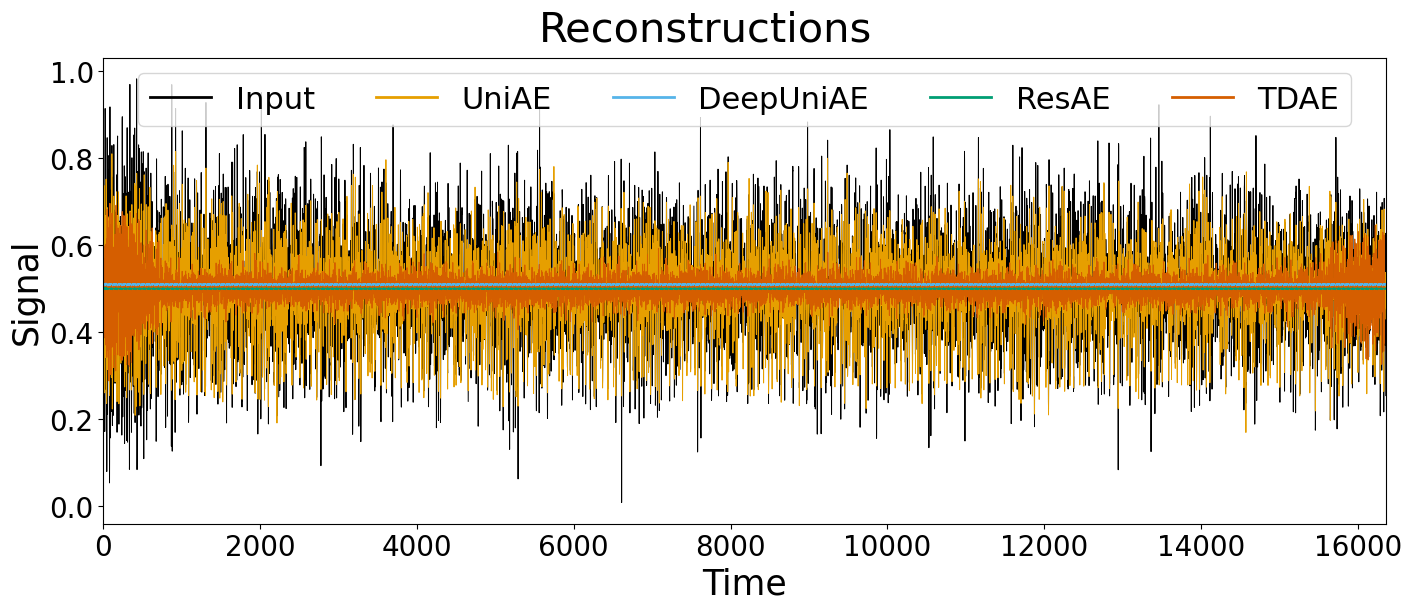

In [33]:
inp = torch.hstack([sample_uni[0, :, 0]] + [sample_uni[i, -win_stride_uni:, 0] for i in range(1, sample_uni.shape[0])]).to('cpu')

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
fig.suptitle('Reconstructions', fontsize=30)

ax.plot(inp, c='k', lw=.7, label='Input')
for key, item in out.items():
    ax.plot(item['rec'], c=item['C'], lw=.7, label=key, zorder=item['zorder'])
    
ax.set_xlim(0, len(inp))
leg = ax.legend(loc='upper center', ncols=5, fontsize=22, markerscale=3)
for line in leg.get_lines(): line.set_linewidth(2)
ax.set_xlabel('Time', fontsize=25)
ax.set_ylabel('Signal', fontsize=25)
ax.tick_params(labelsize=20)
# plt.savefig('/mnt/eph/report_figures/reconstructions.pdf')  ######### DANGER ZONE #########
plt.show()

# GG

In [132]:
noise_subtest = grid[:3000]
inj_substest = grid[-3000:]
print(noise_subtest.shape, inj_substest.shape)

(3000, 272) (3000, 272)


In [133]:
thresh = .013
print(np.mean(np.any((noise_subtest > thresh) & np.pad((noise_subtest > thresh), ((0,0), (0,1)))[:, 1:], axis=1)))
print(np.mean(np.any((inj_substest > thresh) & np.pad((inj_substest > thresh), ((0,0), (0,1)))[:, 1:], axis=1)))

1.0
1.0


In [134]:
thresh = .015
testing = np.any(grid > thresh, axis=1)
print('fp', np.mean(testing[:3000]))
print('tp', np.mean(testing[-3000:]))

fp 1.0
tp 1.0


value: 0.005876645
tolerance:: 0.0106865205
number of elements exceeding threshold: 7905
number on elements in noise-only samples: 1350
number on elements in noise-signal samples: 6555


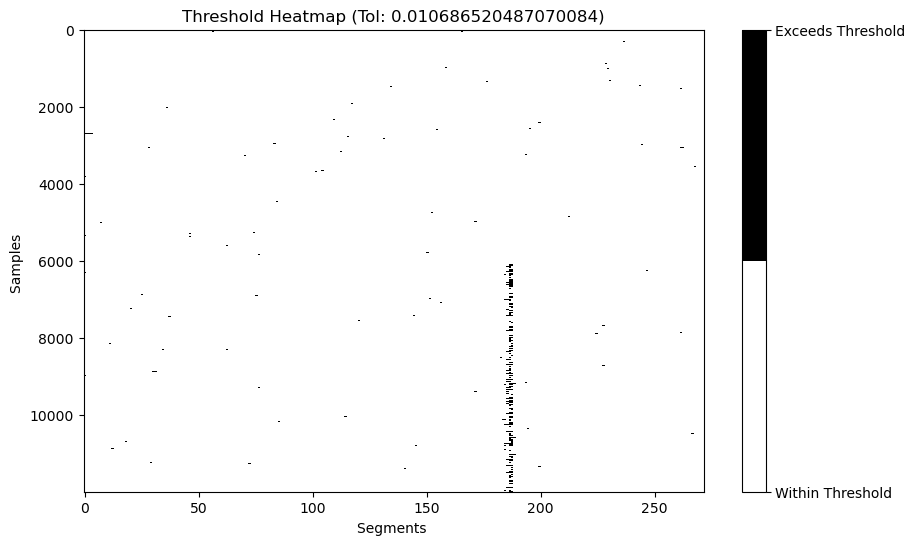

In [18]:
### Warning: Ai copy paste below (esploration and ideas validation purpose only)
import matplotlib.colors as mcolors

value = grid.mean()
print("value:", value)
thresh = value + 2*grid.std()
print("tolerance::",thresh)

mask = np.abs(grid - value) > thresh

print("number of elements exceeding threshold:", np.sum(mask))
print("number on elements in noise-only samples:", np.sum(mask[:5999,:]))
print("number on elements in noise-signal samples:", np.sum(mask[5999:,:]))

plt.figure(figsize=(10, 6))

cmap = mcolors.ListedColormap(['white', 'black'])

plt.imshow(mask, cmap=cmap, aspect='auto', interpolation='nearest') # maybe we can use bigger windows not just picking some random ones

cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(['Within Threshold', 'Exceeds Threshold'])

plt.xlabel('Segments ')
plt.ylabel('Samples ')
plt.title(f'Threshold Heatmap (Tol: {thresh})')
plt.show()

In [23]:
# i think a better indicator should be found.
# also we cannot count just the segments that go over the thresh bc a signal is made of many segments. wee need a better way to aggregate.

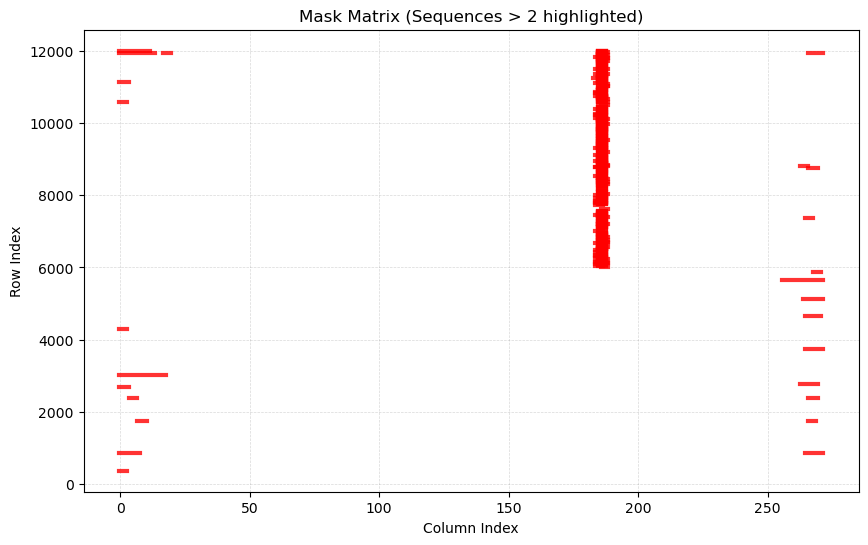

In [19]:
from scipy.ndimage import label

def find_consecutive_trues(mask, x_threshold):
    """
    Finds rows where there are more than x_threshold consecutive True values.
    Returns the row index and the start/end column indices.
    """
    results = []
    
    for row_idx, row in enumerate(mask):
        # Label consecutive groups of True values
        # structure=[1,1,1] ensures we only look horizontally
        labeled_array, num_features = label(row)
        
        for feat in range(1, num_features + 1):
            # Find coordinates of this specific group
            indices = np.where(labeled_array == feat)[0]
            
            if len(indices) > x_threshold:
                results.append({
                    'row': row_idx,
                    'start': indices[0],
                    'end': indices[-1],
                    'count': len(indices)
                })
    return results


X = 2
matches = find_consecutive_trues(mask, X)

# --- Visualization ---
plt.figure(figsize=(10, 6))
#plt.imshow(mask, cmap='gray_r', interpolation='nearest')

# Highlight the found sequences
for m in matches:
    # Drawing a red box around the sequence
    plt.plot([m['start']-0.5, m['end']+0.5], [m['row'], m['row']], 
             color='red', linewidth=3, alpha=0.8)

plt.title(f"Mask Matrix (Sequences > {X} highlighted)")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.show()